In [2]:
import rmgpy
import numpy as np
from arkane.main import get_git_commit
from rmgpy.molecule.molecule import *
from rmgpy.species import *
from rmgpy.chemkin import *
from rmgpy.data.rmg import RMGDatabase
from IPython.display import display
from rmgpy.data.thermo import ThermoLibrary
from rmgpy.rmg.react import react
from rmgpy.species import Species
from rmgpy.reaction import Reaction
from rmgpy.data.rmg import get_db
from rmgpy.molecule.group import Group
from rmgpy.kinetics.arrhenius import ArrheniusBM
from rmgpy.data.kinetics.family import _make_rule
from rmgpy import settings
import time
import matplotlib.pyplot as plt
import matplotlib
import importlib
import sys
import datetime
matplotlib.use('Agg')
%matplotlib inline

In [3]:
settings

{'database.directory': '/home/khalil.nor/Code/RMG-database/input',
 'test_data.directory': '/home/khalil.nor/Code/RMG-Py/rmgpy/test_data'}

In [4]:
print(f"For this retraining, you are on the following\nRMG-database: {get_git_commit(settings['database.directory'])}\nRMG-Py: {get_git_commit('/home/khalil.nor/Code/RMG-Py/rmgpy')}")

For this retraining, you are on the following
RMG-database: ('aca03f207fedcc63aeea52030ebcbbbdd5002625', 'Wed Feb 12 15:09:30 2025 -0500')
RMG-Py: ('ad51418fecf4fd8651fbef4cc09f21ecf6634f41', 'Thu Jun 22 21:50:08 2023 -0400')


In [ ]:
#this is testing to see if we can take a super old commit from rebased branch of RMG-Py and seeing what our rates were.
#hoped I could do git bisect on the rebased branch, but even the old commit has a really bad root node fit. 
#DF used his revised fitting on this branch for a reason then. 

In [5]:
thermo_libs = [
'C1_C2_Fluorine', #adding Siddha's as first most trusted because this is the thermo library that Franklin used
'PFCA_thermo',
#'NCSU_C2_C8_PFAS', #adding Westmoreland's thermo as the second most trusted
'primaryThermoLibrary',
'Fluorine',
'FFCM1(-)',
'halogens',
'CHOF_G4',
'CHOCl_G4',
'CHOBr_G4',
'CHOFCl_G4',
'CHOFBr_G4',
'CHOFClBr_G4',
'DFT_QCI_thermo',
'2-BTP_G4',
'thermo_DFT_CCSDTF12_BAC',
'SulfurHaynes'
]

kin_families = ['1+2_Cycloaddition']

In [6]:
database = RMGDatabase()
database.load(
            path = settings['database.directory'],
            thermo_libraries = thermo_libs,
            transport_libraries = [],
            reaction_libraries = [],
            seed_mechanisms = [],#['BurkeH2O2inN2','ERC-FoundationFuelv0.9'],
            kinetics_families = kin_families,
            kinetics_depositories = ['training'],
            #frequenciesLibraries = self.statmechLibraries,
            depository = False, # Don't bother loading the depository information, as we don't use it
        )

In [7]:
database.kinetics.families

{'1+2_Cycloaddition': <ReactionFamily "1+2_Cycloaddition">}

In [8]:
family_to_train = kin_families[0]
family = database.kinetics.families[family_to_train]

In [9]:
family.clean_tree()

In [10]:
start = time.time()
family.generate_tree(thermo_database=database.thermo,
                     nprocs=1,
                     new_fraction_threshold_to_reopt_node=0.25,
                     max_batch_size=800,
                     extension_iter_max=2,
                     extension_iter_item_cap=100)

end = time.time()
print(end-start)

ERROR:root:42.0
ERROR:root:iter_max achieved terminating early
ERROR:root:iter_max achieved terminating early
ERROR:root:iter_max achieved terminating early
ERROR:root:iter_max achieved terminating early
ERROR:root:iter_max achieved terminating early
ERROR:root:iter_max achieved terminating early
ERROR:root:iter_max achieved terminating early
ERROR:root:iter_max achieved terminating early
ERROR:root:iter_max achieved terminating early
ERROR:root:iter_max achieved terminating early


13.708654165267944


In [11]:
len(family.groups.entries)

65

In [12]:
#let's see the group entries

#before: 
#after: 

family.groups.entries

{'cycle': <Entry index=-1 label="cycle">,
 'Root': <Entry index=0 label="Root">,
 'Root_Ext-3R-R': <Entry index=1 label="Root_Ext-3R-R">,
 'Root_1R->C': <Entry index=2 label="Root_1R->C">,
 'Root_N-1R->C': <Entry index=3 label="Root_N-1R->C">,
 'Root_Ext-3R-R_Sp-4R!H-3R': <Entry index=4 label="Root_Ext-3R-R_Sp-4R!H-3R">,
 'Root_Ext-3R-R_N-Sp-4R!H-3R': <Entry index=5 label="Root_Ext-3R-R_N-Sp-4R!H-3R">,
 'Root_1R->C_Ext-1C-R': <Entry index=6 label="Root_1R->C_Ext-1C-R">,
 'Root_1R->C_Ext-2R-R': <Entry index=7 label="Root_1R->C_Ext-2R-R">,
 'Root_1R->C_Sp-2R=1C': <Entry index=8 label="Root_1R->C_Sp-2R=1C">,
 'Root_1R->C_N-Sp-2R=1C': <Entry index=9 label="Root_1R->C_N-Sp-2R=1C">,
 'Root_Ext-3R-R_Sp-4R!H-3R_4R!H->O': <Entry index=10 label="Root_Ext-3R-R_Sp-4R!H-3R_4R!H->O">,
 'Root_Ext-3R-R_Sp-4R!H-3R_N-4R!H->O': <Entry index=11 label="Root_Ext-3R-R_Sp-4R!H-3R_N-4R!H->O">,
 'Root_Ext-3R-R_N-Sp-4R!H-3R_Ext-2R-R': <Entry index=12 label="Root_Ext-3R-R_N-Sp-4R!H-3R_Ext-2R-R">,
 'Root_1R->C_Ext

In [13]:
#check the tree
start = time.time()
family.check_tree()
end = time.time()
print(end-start)

0.009443998336791992


In [14]:
#regularize
start = time.time()
family.regularize(thermo_database=database.thermo)
end = time.time()
print(end-start)

2.049269199371338


In [15]:
#get reaction matches
start = time.time()
templateRxnMap = family.get_reaction_matches(thermo_database=database.thermo,remove_degeneracy=True,
                                             get_reverse=True,exact_matches_only=False,fix_labels=True)
end = time.time()
print(end-start)

2.067901134490967


In [16]:
len(templateRxnMap)

65

In [ ]:
for node_label, reactions in templateRxnMap.items(): 
    print('=======================================================================')
    print(node_label)
    for rxn in reactions: 
        print(rxn)

### start here when playing around with Arrhenius.pyx

In [17]:
family.clean_tree_rules()

In [18]:
#make sure its clean
family.rules.entries

OrderedDict([('Root', [])])

In [19]:
#WAS RUNNING THIS BEFORE
start = time.time()
family.make_bm_rules_from_template_rxn_map(templateRxnMap)#,nprocs=6)
end = time.time()
print(end-start)

/home/khalil.nor/Code/RMG-Py/rmgpy/data/kinetics/family.py:3617: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  for rxns, label in rxnlists])
/work/westgroup/nora/miniconda/envs/rmg_env/lib/python3.7/site-packages/scipy/optimize/minpack.py:834: OptimizeWarning: Covariance of the parameters could not be estimated
  category=OptimizeWarning)
/work/westgroup/nora/miniconda/envs/rmg_env/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3441: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/work/westgroup/nora/miniconda/envs/rmg_env/lib/python3.7/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


2.0950088500976562


In [20]:
len(family.rules.entries)

65

In [21]:
start = time.time()
family.check_tree()
end = time.time()
print(end-start)

0.011144638061523438


In [22]:
start = time.time()
errors,uncertainties = family.cross_validate(iters=0,random_state=5,folds=0)#,ascend=False)
end = time.time()
print(end-start)

2.0595948696136475


/work/westgroup/nora/miniconda/envs/rmg_env/lib/python3.7/site-packages/scipy/optimize/minpack.py:834: OptimizeWarning: Covariance of the parameters could not be estimated
  category=OptimizeWarning)


Text(0.5, 0, '$|Ln(k_{est}/k_{rxn})|$')

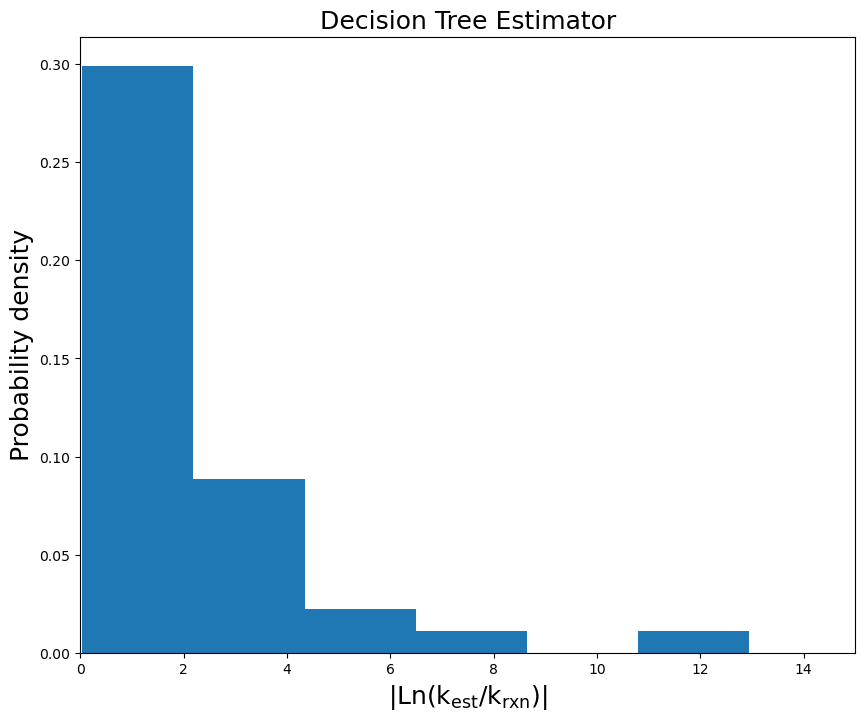

In [23]:
%matplotlib inline
plt.figure(figsize=(10,8))
plt.hist(np.abs(list(errors.values())),bins=30, density=True)
plt.title('Decision Tree Estimator',fontsize=18)
#plt.ylim(0,.4)
plt.xlim(0,15)
plt.ylabel('Probability density',fontsize=18)
plt.xlabel(r'$|Ln(k_{est}/k_{rxn})|$',fontsize=18)

In [24]:
#also save to this folder 
save_here = './'
family.save(save_here)

In [ ]:
#LOOK AT RULES.PY before proceeding. Check for weird A's and n's

In [ ]:
### still getting a really bad fit for root node. Even with DF's changes to Arrhenius.pyx cherry picked on the rebased branch, still getting terrible node rate. 

Going to start looking at _make_rule_ next

In [ ]:
save_path = os.path.join(settings['database.directory'], 'kinetics', 'families', family.name)
print(save_path)


In [ ]:
family.save(save_path)
print(f'Saved family to RMG database on {datetime.datetime.now()}')

In [ ]:
#compare the new rate to the old rate 

In [ ]:
#let's recalculate the rate with the rules.py that was generated by this retraining
#RESTART THE KERNAL AFTER SAVING new rules.py TO RMG-database, then we'll calculate the new rate
import rmgpy
import numpy as np
from arkane.main import get_git_commit
from rmgpy.molecule.molecule import *
from rmgpy.species import *
from rmgpy.chemkin import *
from rmgpy.data.rmg import RMGDatabase
from IPython.display import display
from rmgpy.data.thermo import ThermoLibrary
from rmgpy.rmg.react import react
from rmgpy.species import Species
from rmgpy.reaction import Reaction
from rmgpy.data.rmg import get_db
from rmgpy.molecule.group import Group
from rmgpy.kinetics.arrhenius import ArrheniusBM
from rmgpy.data.kinetics.family import _make_rule
from rmgpy import settings
import time
import matplotlib.pyplot as plt
import matplotlib
import importlib
import sys
import datetime
matplotlib.use('Agg')
%matplotlib inline

In [ ]:
thermo_libs = [
'C1_C2_Fluorine', #adding Siddha's as first most trusted because this is the thermo library that Franklin used
'PFCA_thermo',
#'NCSU_C2_C8_PFAS', #adding Westmoreland's thermo as the second most trusted
'primaryThermoLibrary',
'Fluorine',
'FFCM1(-)',
'halogens',
'CHOF_G4',
'CHOCl_G4',
'CHOBr_G4',
'CHOFCl_G4',
'CHOFBr_G4',
'CHOFClBr_G4',
'DFT_QCI_thermo',
'2-BTP_G4',
'thermo_DFT_CCSDTF12_BAC',
'SulfurHaynes'
]

kin_families = ['1+2_Cycloaddition']


database = RMGDatabase()
database.load(
            path = settings['database.directory'],
            thermo_libraries = thermo_libs,
            transport_libraries = [],
            reaction_libraries = [],
            seed_mechanisms = [],#['BurkeH2O2inN2','ERC-FoundationFuelv0.9'],
            kinetics_families = kin_families,
            kinetics_depositories = ['training'],
            #frequenciesLibraries = self.statmechLibraries,
            depository = False, # Don't bother loading the depository information, as we don't use it
        )

In [ ]:
database.kinetics.families

In [ ]:
my_reactants = [
    #Species(label="O-2(150)", thermo=NASA(polynomials=[NASAPolynomial(coeffs=[2.5,-3.01681e-12,3.74582e-15,-1.50857e-18,1.86626e-22,51997.4,2.99252], Tmin=(100,'K'), Tmax=(4879.8,'K')), NASAPolynomial(coeffs=[4.28461,-0.00145495,4.44804e-07,-6.0436e-11,3.07922e-15,50246.3,-8.45564], Tmin=(4879.8,'K'), Tmax=(5000,'K'))], Tmin=(100,'K'), Tmax=(5000,'K'), E0=(432.331,'kJ/mol'), Cp0=(20.7862,'J/(mol*K)'), CpInf=(20.7862,'J/(mol*K)'), label="""O(S)""", comment="""Thermo library: primaryThermoLibrary"""), molecule=[Molecule(smiles="O")]),
    Species(label="O-2(150)", thermo=NASA(polynomials=[NASAPolynomial(coeffs=[2.5,-3.01681e-12,3.74582e-15,-1.50857e-18,1.86626e-22,51997.4,2.99252], Tmin=(100,'K'), Tmax=(4879.8,'K')), NASAPolynomial(coeffs=[4.28461,-0.00145495,4.44804e-07,-6.0436e-11,3.07922e-15,50246.3,-8.45564], Tmin=(4879.8,'K'), Tmax=(5000,'K'))], Tmin=(100,'K'), Tmax=(5000,'K'), E0=(432.331,'kJ/mol'), Cp0=(20.7862,'J/(mol*K)'), CpInf=(20.7862,'J/(mol*K)'), label="""O(S)""", comment="""Thermo library: primaryThermoLibrary""")).from_adjacency_list('O-2(150)\n1 O u0 p3 c0\n'),
                Species(label="CFOOH(127)", thermo=NASA(polynomials=[NASAPolynomial(coeffs=[0.697783,0.0285739,-3.24394e-05,1.82244e-08,-3.96446e-12,-74951.3,21.0926], Tmin=(200,'K'), Tmax=(1000,'K')), NASAPolynomial(coeffs=[6.02782,0.00900158,-5.18115e-06,1.38568e-09,-1.41746e-13,-76136.1,-5.12554], Tmin=(1000,'K'), Tmax=(3000,'K'))], Tmin=(200,'K'), Tmax=(3000,'K'), E0=(-625.776,'kJ/mol'), Cp0=(33.2579,'J/(mol*K)'), CpInf=(103.931,'J/(mol*K)'), label="""FC_O_OH""", comment="""Thermo library: PFCA_thermo"""), molecule=[Molecule(smiles="O=C(O)F")])]
             
my_products = [Species(label="OC1(F)OO1(939)", thermo=NASA(polynomials=[NASAPolynomial(coeffs=[3.0344,0.0227076,-1.77147e-05,6.60012e-09,-1.01075e-12,-57686,12.7935], Tmin=(100,'K'), Tmax=(1468.49,'K')), NASAPolynomial(coeffs=[7.35558,0.0109375,-5.69219e-06,1.14226e-09,-8.16062e-14,-58955.1,-9.71412], Tmin=(1468.49,'K'), Tmax=(5000,'K'))], Tmin=(100,'K'), Tmax=(5000,'K'), E0=(-479.905,'kJ/mol'), Cp0=(33.2579,'J/(mol*K)'), CpInf=(128.874,'J/(mol*K)'), comment="""Thermo group additivity estimation: group(O2s-OsCs) + group(O2s-OsCs) + group(O2s-CsH) + group(CsFOOO) + ring(O2s-O2s-Cs(F))"""), molecule=[Molecule(smiles="OC1(F)OO1")])]   

In [ ]:
for reac in my_reactants:
    print(reac.to_adjacency_list())

In [ ]:
Species().from_adjacency_list('O-2(150)\n1 O u0 p3 c0\n')



In [ ]:
fam_rxn_list = database.kinetics.generate_reactions(
        reactants=my_reactants,
        products=my_products,
        resonance=True,
    )


In [ ]:
print(fam_rxn_list) #this is what it matched to after this retraining
template = database.kinetics.families[kin_families[0]].retrieve_template(fam_rxn_list[0].template)
print('**** Estimated kinetics:\n\n\n')
kinetics = database.kinetics.families[kin_families[0]].get_kinetics_for_template(template)
print(kinetics[0].to_arrhenius(-28514.3047311871)) #this is the dHrxn of the pdep reaction


#for some reason, this matches the "after" rate of the 



In [ ]:
#old rates from before: 
old_rates = [-54.71759611586142, -43.39043899064641, -34.75715876600344, -27.954520199721603, -22.452926623065768, -17.909364334880085, -14.091842477022908, -10.837810315327259, -8.029966970116378, -5.581528246482763, -3.426900185748561, -1.5155774377221274, 0.19196386527231346, 1.7271002583293733, 3.115059948691873, 4.376360434347584, 5.527860506166267, 6.583542187624295, 7.555100208147497, 8.452392124206499]



In [ ]:
#check nodes 

temperatures = np.array([ 300., 500.,  600.,  700. , 800.,  900., 1000., 1100., 1200., 1500., 2000.])
inverse_temps = [1000/T for T in temperatures]

def get_tr_rate(tr_rxn): 
    """Get training reaction rates over the range of temperatures"""
    log_tr_rates = []
    for temp in temperatures: 
        tr_rate = tr_rxn.get_rate_coefficient(temp)
        log_tr_rates.append(np.log(tr_rate))
    return log_tr_rates


def plot_node(node_label): 
    """
    Plot all of the rxns in the node and the fit for that node. 
    """
    #beginning of plotting 
    plt.ion()  # Enable interactive mode
    plt.figure()
    fig, ax = plt.subplots()

    
    #first get the BM rule of the node
    try: 
        BM_rule = family.retrieve_original_entry(node_label)[0].data
    except ValueError:
        return
    
    #second, let's get the training reactions of that node
    training_rxns = templateRxnMap[node_label]
    
    #calculate the rates for all of training reactions across all temps 
    for tr_rxn in training_rxns: 
        log_tr_rates = get_tr_rate(tr_rxn)
        ax.plot(inverse_temps, log_tr_rates, '-o', c= 'black', label = str(tr_rxn))

        
    #define initial parameters 
    init_index_of_training_rxn = 0 #initialize with any of the training reaction indices
        
    def get_BM_rate_at_this_dH(index_of_training_rxn):
        log_BM_rates = []
        dH = training_rxns[index_of_training_rxn].get_enthalpy_of_reaction(298)
        for temp in temperatures: 
            BM_rate = BM_rule.get_rate_coefficient(temp, dH)
            log_BM_rates.append(np.log(BM_rate))
        return log_BM_rates #returns ydata
    
    #plot the BM fit 
    line = ax.plot(inverse_temps, get_BM_rate_at_this_dH(init_index_of_training_rxn), c='r', lw=2)
    ax.set_xlabel('1000/T')
    ax.set_ylabel('ln(k)')
    plt.title(node_label)
    #plt.legend()
    plt.show()

    
%matplotlib inline
#doing one node at a time 
#testing
entries = list(family.groups.entries.values())
Tref=1000.0
fmax=1.0e5
completed_nodes = 0 


rule_keys = family.rules.entries.keys()
for entry in family.groups.entries.values():
    if entry.label not in rule_keys:
        family.rules.entries[entry.label] = []


for node_name, rxns_list in templateRxnMap.items():
    
    subset_dict = {}
    subset_dict[node_name] = rxns_list
    plot_node(node_name)

    


In [ ]:
## we have three training reactions that double matched to R_addition_multiplebond and CO_CF_bond_dissociation

In [ ]:
entry(
    index = 26,
    label = "C4F9O <=> C2F4O-2 + C2F5",
    degeneracy = 1.0,
    kinetics = Arrhenius(A=(2.59E+10,'1/s'), n=0.65, Ea=(22327.43,'cal/mol'), T0=(1,'K')),
    rank = 3,
    longDesc = 
"""
Training reaction from kinetics library: PFAS_HPL_Test/R_Addition_MultipleBond/ (MULTIPLE MATCHING with CO_CF_Bond_Diss & R_Addition_multiple_bond. Only added training reaction in here.)
Original entry: C2F5OCFCF3 <=> CF3CFO+C2F5
""",
)

entry(
    index = 27,
    label = "CF3OCF2 <=> CF3+CF2O",
    degeneracy = 1.0,
    kinetics = Arrhenius(A=(5.95E+09,'1/s'), n=1.2, Ea=(27353.48,'cal/mol'), T0=(1,'K')),
    rank = 3,
    longDesc = 
"""
Training reaction from kinetics library: PFAS_HPL_Test/R_Addition_MultipleBond/ (MULTIPLE MATCHING with CO_CF_Bond_Diss & R_Addition_multiple_bond. Only added training reaction in here.)
Original entry: CF3OCF2 <=> CF3+CF2O
""",
)

entry(
    index = 28,
    label = "C2H5OCHCH3 <=> C2H4O+C2H5",
    degeneracy = 1.0,
    kinetics = Arrhenius(A=(2.78E+10,'1/s'), n=0.74, Ea=(22459.57,'cal/mol'), T0=(1,'K')),
    rank = 3,
    longDesc = 
"""
Training reaction from kinetics library: PFAS_HPL_Test/R_Addition_MultipleBond/ (MULTIPLE MATCHING with CO_CF_Bond_Diss & R_Addition_multiple_bond. Only added training reaction in here.)
Original entry: C2H5OCHCH3 <=> CH3CHO+C2H5
""",
)

In [ ]:
#C4F9O <=> C2F4O-2 + C2F5
rxn_1_reactant_adjlist = """
multiplicity 2
1     F u0 p3 c0 {11,S}
2     F u0 p3 c0 {11,S}
3     F u0 p3 c0 {12,S}
4     F u0 p3 c0 {12,S}
5     F u0 p3 c0 {12,S}
6     F u0 p3 c0 {13,S}
7     F u0 p3 c0 {13,S}
8     F u0 p3 c0 {13,S}
9     F u0 p3 c0 {14,S}
10    O u0 p2 c0 {11,S} {14,S}
11    C u0 p0 c0 {1,S} {2,S} {10,S} {12,S}
12    C u0 p0 c0 {3,S} {4,S} {5,S} {11,S}
13    C u0 p0 c0 {6,S} {7,S} {8,S} {14,S}
14    C u1 p0 c0 {9,S} {10,S} {13,S}
"""

rxn_1_prod1_adjlist = """
1    F u0 p3 c0 {6,S}
2    F u0 p3 c0 {6,S}
3    F u0 p3 c0 {6,S}
4    F u0 p3 c0 {7,S}
5    O u0 p2 c0 {7,D}
6    C u0 p0 c0 {1,S} {2,S} {3,S} {7,S}
7    C u0 p0 c0 {4,S} {5,D} {6,S}
"""

rxn_1_prod2_adjlist = """
multiplicity 2
1  C  u0 p0 c0 {2,S} {3,S} {4,S} {5,S}
2  F  u0 p3 c0 {1,S}
3  F  u0 p3 c0 {1,S}
4  F  u0 p3 c0 {1,S}
5  C  u1 p0 c0 {1,S} {6,S} {7,S}
6  F  u0 p3 c0 {5,S}
7  F  u0 p3 c0 {5,S}
"""

rxn_1_reactant = Species(label="C4F9O").from_adjacency_list(rxn_1_reactant_adjlist)
rxn_1_prod1 = Species(label="C2F4O-2").from_adjacency_list(rxn_1_prod1_adjlist)
rxn_1_prod2 = Species(label="C2F5").from_adjacency_list(rxn_1_prod2_adjlist)


#CF3OCF2 <=> CF3+CF2O

rxn_2_reactant_adjlist = """
multiplicity 2
1  C  u1 p0 c0 {2,S} {3,S} {4,S}
2  O  u0 p2 c0 {1,S} {5,S}
3  F  u0 p3 c0 {1,S}
4  F  u0 p3 c0 {1,S}
5  C  u0 p0 c0 {2,S} {6,S} {7,S} {8,S}
6  F  u0 p3 c0 {5,S}
7  F  u0 p3 c0 {5,S}
8  F  u0 p3 c0 {5,S}
"""

rxn_2_prod1_adjlist = """
multiplicity 2
1  C  u1 p0 c0 {2,S} {3,S} {4,S}
2  F  u0 p3 c0 {1,S}
3  F  u0 p3 c0 {1,S}
4  F  u0 p3 c0 {1,S}
"""

rxn_2_prod2_adjlist = """
1    F u0 p3 c0 {4,S}
2    F u0 p3 c0 {4,S}
3    O u0 p2 c0 {4,D}
4    C u0 p0 c0 {1,S} {2,S} {3,D}
"""

rxn_2_reactant = Species(label="CF3OCF2").from_adjacency_list(rxn_2_reactant_adjlist)
rxn_2_prod1 = Species(label="CF3").from_adjacency_list(rxn_2_prod1_adjlist)
rxn_2_prod2 = Species(label="CF2O").from_adjacency_list(rxn_2_prod2_adjlist)



#C2H5OCHCH3 <=> C2H4O+C2H5
rxn_3_reactant_adjlist = """
multiplicity 2
1  C  u0 p0 c0 {2,S} {3,S} {4,S} {14,S}
2  H  u0 p0 c0 {1,S}
3  H  u0 p0 c0 {1,S}
4  C  u1 p0 c0 {1,S} {5,S} {6,S} 
5  H  u0 p0 c0 {4,S}
6  O  u0 p2 c0 {4,S} {7,S}
7  C  u0 p0 c0 {6,S} {8,S} {9,S} {10,S}
8  H  u0 p0 c0 {7,S}
9  H  u0 p0 c0 {7,S}
10 C  u0 p0 c0 {7,S} {11,S} {12,S} {13,S}
11 H  u0 p0 c0 {10,S}
12 H  u0 p0 c0 {10,S}
13 H  u0 p0 c0 {10,S}
14 H  u0 p0 c0 {1,S}
"""

rxn_3_prod1_adjlist = """
1    O u0 p2 c0 {3,D}
2    C u0 p0 c0 {3,S} {4,S} {5,S} {6,S}
3    C u0 p0 c0 {1,D} {2,S} {7,S}
4    H u0 p0 c0 {2,S}
5    H u0 p0 c0 {2,S}
6    H u0 p0 c0 {2,S}
7    H u0 p0 c0 {3,S}
"""

rxn_3_prod2_adjlist = """
multiplicity 2
1  C  u0 p0 c0 {2,S} {3,S} {4,S} {5,S}
2  H  u0 p0 c0 {1,S}
3  H  u0 p0 c0 {1,S}
4  H  u0 p0 c0 {1,S}
5  C  u1 p0 c0 {1,S} {6,S} {7,S}
6  H  u0 p0 c0 {5,S}
7  H  u0 p0 c0 {5,S}
"""

rxn_3_reactant = Species(label="C2H5OCHCH3").from_adjacency_list(rxn_3_reactant_adjlist)
rxn_3_prod1 = Species(label="C2H4O").from_adjacency_list(rxn_3_prod1_adjlist)
rxn_3_prod2 = Species(label="C2H5").from_adjacency_list(rxn_3_prod2_adjlist)



#CH3OCHC(O)OH <=> CH2C(O)OH+CH2O
rxn_4_reactant_adjlist = """
multiplicity 2
1  C  u0 p0 c0 {2,D} {3,S} {5,S}
2  O  u0 p2 c0 {1,D}
3  O  u0 p2 c0 {1,S} {4,S}
4  H  u0 p0 c0 {3,S}
5  C  u1 p0 c0 {1,S} {6,S} {7,S}
6  H  u0 p0 c0 {5,S}
7  O  u0 p2 c0 {5,S} {8,S}
8  C  u0 p0 c0 {7,S} {9,S} {10,S} {11,S}
9  H  u0 p0 c0 {8,S}
10 H  u0 p0 c0 {8,S}
11 H  u0 p0 c0 {8,S}
"""
rxn_4_prod1_adjlist = """
multiplicity 2
1  C  u0 p0 c0 {2,D} {3,S} {5,S}
2  O  u0 p2 c0 {1,D}
3  O  u0 p2 c0 {1,S} {4,S}
4  H  u0 p0 c0 {3,S}
5  C  u1 p0 c0 {1,S} {6,S} {7,S}
6  H  u0 p0 c0 {5,S}
7  H  u0 p0 c0 {5,S}
"""
rxn_4_prod2_adjlist = """
1    O u0 p2 c0 {2,D}
2    C u0 p0 c0 {1,D} {3,S} {4,S}
3    H u0 p0 c0 {2,S}
4    H u0 p0 c0 {2,S}
"""

rxn_4_reactant = Species(label="CH3OCHC(O)OH").from_adjacency_list(rxn_4_reactant_adjlist)
rxn_4_prod1 = Species(label="CH2C(O)OH").from_adjacency_list(rxn_4_prod1_adjlist)
rxn_4_prod2 = Species(label="CH2O").from_adjacency_list(rxn_4_prod2_adjlist)

In [ ]:
# Estimate the kinetics

training_rxn_species = [
    ([rxn_4_reactant], [rxn_4_prod1, rxn_4_prod2]),

    # ([rxn_1_reactant], [rxn_1_prod1, rxn_1_prod2]),
    # ([rxn_2_reactant], [rxn_2_prod1, rxn_2_prod2]),
    # ([rxn_3_reactant], [rxn_3_prod1, rxn_3_prod2]),
]

for reactants_, products_ in training_rxn_species: 
    print(reactants_[0].label, products_[0].label, products_[1].label)
    fam_rxn_list = database.kinetics.generate_reactions_from_families(
        reactants=reactants_,
        products=products_,
        only_families=['CO_CF_bond_dissociation'],
        resonance=True,
    )
    
    database.kinetics.families['CO_CF_bond_dissociation'].add_atom_labels_for_reaction(fam_rxn_list[0])
    for spc in fam_rxn_list[0].reactants+fam_rxn_list[0].products:
        print(spc.label)
        print(spc.to_adjacency_list())
        
    
